# This notebook contains the answer of all the execises made for the RobMOOC.

The summary:

- Ex 1: Crank
- Ex 2: Pools
- Ex 3: Robot Tank


# Exercice 1. Manivelle
#### Leçon A. Introduction au bouclage linéarisant

### 1) Give the state equations of the robot. We will take the state vector x = (x1, x2) .

Une fermeture cinématique nous permet de déduire la sortie y par:   
#### $y = \binom{y_1}{y_2} = \binom{l_1.cos(x_1) + l_2.cos(x_1 + x_2)}{l_1.sin(x_1) + l_2.sin(x_1 + x_2)} $ 

La manivelle sera commandée par la vitesse d'un moteur à chaque articulation. On note ce vecteur de vitesse angulaire u, et on a donc:

#### $u = \binom{u_1}{u_2} = \binom{\dot{x}_1} {\dot{x}_2} $ 

L'équation d'état du robot est donc:

$$ \begin{cases} \dot{x}_1 = u_1 \\ \dot{x}_2 = u_2 \\ y_1 = l_1.cos(x_1) + l_2.cos(x_1 + x_2) \\ y_2 = l_1.sin(x_1) + l_2.sin(x_1 + x_2) \end{cases} $$


Le code représentant le modèle de cette manivelle est le suivant:

In [ ]:
from roblib import *

l1,l2 = 4,3
c = np.array([[3],[4]])
r=1
dt = 0.05

x = np.array([[0],[0]])
y = l1*np.array([[np.cos(x[0,0])],[np.sin(x[0,0])]]) + l2*np.array([[np.cos(x[0,0]+x[1,0])],[np.sin(x[0,0]+x[1,0])]])



Pour pouvoir tracer le coude de la manivelle, on introduit le point intermédiare z définit par:  

#### $z = \binom{z_1}{z_2} = \binom{l_1.cos(x_1) }{l_1.sin(x_1) } $  et donc  
#### $y = z + \binom{ l_2.cos(x_1 + x_2)}{ l_2.sin(x_1 + x_2)} $   

On réécrit donc le code :

In [ ]:
# On prend les angles x en radiant suivant:
x = np.array([[-1],[2]])

z = l1*np.array([[np.cos(x[0,0])],[np.sin(x[0,0])]]) 
y = z + l2*np.array([[np.cos(x[0,0]+x[1,0])],[np.sin(x[0,0]+x[1,0])]])


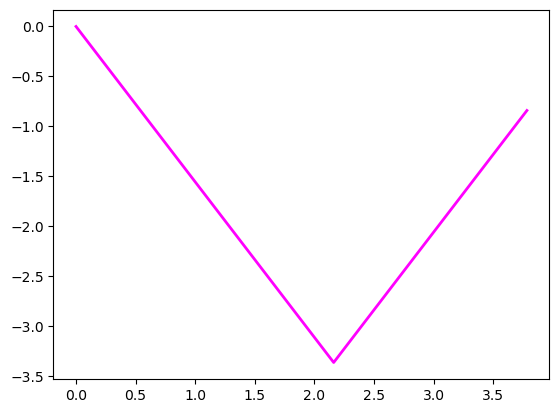

In [ ]:
# On trace un exemple de configuration de la manivelle:
plot( [0,z[0,0],y[0,0]],[0,z[1,0],y[1,0]],'magenta', linewidth = 2)
show()


Si l'on désire contrôler la manivelle avec la commande en vitesse des moteurs, on peut ici créer les fonctions z(x) et y(x), avec x calculé à partir de l'intégrale de la commande u, calculé sur un pas de temps numérique dt: 

In [ ]:
def z(x):
    return l1*np.array([[np.cos(x[0,0])],[np.sin(x[0,0])]])

def y(x):
    return z(x) + l2*np.array([[np.cos(x[0,0]+x[1,0])],[np.sin(x[0,0]+x[1,0])]])

def draw_manivelle(x):
    plot( [0,z(x)[0,0],y(x)[0,0]],[0,z(x)[1,0],y(x)[1,0]],'magenta', linewidth = 2)
    # draw_disk(ax,c,r,"cyan")
    draw_disk(ax, c.flatten(), r, "cyan") 


Pour une commande en vitesse de 1 et 2 radians par secondes par exemple , on aura:

In [ ]:
# # %matplotlib widget
# x = np.array([[-1],[2]]) # position initiale
# dt = 0.05

# ax = plt.figure().gca()
# ax.set_xlim(0, 10); ax.set_ylim(0, 10)
# ax.set_autoscale_on(False)
# ax.grid(True)
# # line1, = ax.plot([], [], 'b+', linewidth=2.0)

# fig = plt.figure()

# for t in np.arange(0,1,0.2):
#     # clear(ax)
#     u = np.array([[1],[2]]) # commande
#     x = x + u*dt
#     fig.canvas.draw()
#     draw_manivelle(x)
#     pause(0.01)
# # ioff()

# show()

#### Le code final a été refait dans un script à part : 01_manivelle.py pour répondre aux problèmes d'animation sur jupyter notebook.

On désire déterminer la commande u de sorte à ce que le point y suive la trajectoire du cercle défini par:  
#### $w = c + r.\binom{ cos(t)}{ sin(t)} $   

Pour ce faire, on va chercher à linéariser le modèle, en dérivant un certain nombre de fois la sortie y jusqu'à retomber sur la commande u:

#### $y = \binom{y_1}{y_2} = \binom{l_1.cos(x_1) + l_2.cos(x_1 + x_2)}{l_1.sin(x_1) + l_2.sin(x_1 + x_2)} $ 


#### $\dot{y} = \binom{\dot{y_1}}{\dot{y_2}} = \binom{-l_1.\dot{x_1}.sin(x_1) - l_2.(\dot{x_1} + \dot{x_2}).sin(x_1 + x_2)}{l_1.\dot{x_1}.cos(x_1) + l_2.(\dot{x_1} + \dot{x_2}).cos(x_1 + x_2)}   $ 

#### $\dot{y} =\binom{-(l_1.sin(x_1) + l_2.sin(x_1 + x_2)).\dot{x_1} - l_2.\dot{x_2}.sin(x_1 + x_2)}{(l_1.cos(x_1) + l_2.cos(x_1 + x_2)).\dot{x_1} + l_2.\dot{x_2}.cos(x_1 + x_2)} $ 

d'où

$$ \dot{y} = \begin{pmatrix} -(l_1.sin(x_1) + l_2.sin(x_1 + x_2)) & - l_2.sin(x_1 + x_2) 
\\ (l_1.cos(x_1) + l_2.cos(x_1 + x_2)) & l_2.cos(x_1 + x_2) \end{pmatrix}  \begin{pmatrix} \dot{x_1} \\ \dot{x_2} \end{pmatrix} $$ 
avec $u = \begin{pmatrix} \dot{x_1} \\ \dot{x_2} \end{pmatrix}  $


On note A(x) la matrice à gauche de u, et on choisit $ u = inv(A(x)).v $ ce qui nous donne alors $  \dot{y} = v $

On a réalisé une seule dérivation, et il n'y a pas de perturbation a priori. On choisit donc un régulateur de type PD de sorte que :

$$ v = \alpha_1.(w-y) + \dot{w} $$

Avec $\alpha_1$ un paramètre à déterminer selon le placement de pôles choisi.

En définissant l'erreur entre la sortie et la consigne par $ e = (y-w) $ , on obtient l'équation différentielle suivante: $ \alpha_1.e +  \dot{e} = 0 $ 

Le polynôme caractéristique de cette équation est $ P(s) = \alpha_1 + s $  

Un placement en -1 comme demandé dans l'énnoncé revient à avoir les racines de se polynôme en -1, ce qui se traduit ici par $\alpha_1 = 1$

#### D'où $v = \binom{c + r(cos(t)-sin(t)) - l_1.cos(x_1) - l_2.cos(x_1 + x_2)}{ c + r(sin(t)+cos(t) ) -l_1.sin(x_1) - l_2.sin(x_1 + x_2)} $

### 3) Study the singularities of the control.

Pour s'assurer que la commande que l'on souhaite réaliser est possible, il faut pouvoir inverser la matrice $A(x)$. Les points où cette matrice ne l'est pas sont les points de singularité. Pour savoir si elle est inversible, on va calculer son déterminant:

$det(A) = det \begin{pmatrix} -(l_1.sin(x_1) + l_2.sin(x_1 + x_2)) & - l_2.sin(x_1 + x_2) 
\\ (l_1.cos(x_1) + l_2.cos(x_1 + x_2)) & l_2.cos(x_1 + x_2) \end{pmatrix}   $  

det est linéaire par rapport à chaque colonne:


$det(A) = det \begin{pmatrix} -l_1.sin(x_1) & - l_2.sin(x_1 + x_2) 
\\ l_1.cos(x_1) & l_2.cos(x_1 + x_2) \end{pmatrix}  +
det \begin{pmatrix} -l_2.sin(x_1 + x_2) & - l_2.sin(x_1 + x_2) 
\\ l_2.cos(x_1 + x_2) & l_2.cos(x_1 + x_2) \end{pmatrix} $   

       
$  = l_1 l_2 det \begin{pmatrix} -sin(x_1) & - sin(x_1 + x_2) 
\\ cos(x_1) & cos(x_1 + x_2) \end{pmatrix}  +
l_2^2 det  \begin{pmatrix} -sin(x_1 + x_2) & - sin(x_1 + x_2) 
\\ cos(x_1 + x_2) & cos(x_1 + x_2) \end{pmatrix} $   


Le terme de droite est nul. Il nous reste:

$det(A) = l_1 l_2 det \begin{pmatrix} -sin(x_1) & - sin(x_1 + x_2) 
\\ cos(x_1) & cos(x_1 + x_2) \end{pmatrix}  =  l_1 l_2 ( sin(x_1 + x_2) cos(x_1) - cos(x_1 + x_2) sin(x_1) )$

On reconnait en trigonométrie la formule de $ sin(a-b) = sin(a)cos(b) - cos(a)sin(b) $, d'où:

$ det(A) = l_1 l_2 sin (x_2) $

Les points de singularités sont déterminés par:

$ det(A) = 0 <=> sin(x_2) = 0 <=> x_2 = k.\pi $ avec $ k \in Z $

Concrètement, cela se produit lorsque les 2 bras sont soit totalement étendus et aligné, soit alignés avec le second bras juxtaposé sur le premier. Le système n'est alors plus contrôlable avec notre commande sur ces deux points, mais la dynamique du système nous permemt de ne pas s'en occupé.

On pourrait le vérifier en commandant le bras de sorte à ce qu'il trace le cercle de centre la jonction des 2 bras et de rayon le bras l2.

Ou un autre test ou le bras n'a pas d'autre choix que dêtre aligné pour suivre la trajectoire du cercle.


Dans les 2 cas, on constate sur l'animation que le bras devient onstable en passant par un de ces points singuliers, et le mouvement est saccadé durant un durans un cours instant. Il arrive que la simulation donne des choses aberrantes avec le bras qui passe d'un côté à l'autre sur un egrande étendue. Le fait d'avoir un det(A) = 0 fait passé la commande vers une valeur infinie, qui est difficilement compréhensible en simulation. 

Ex 1:

# Exercice 2 — Les 3 bacs

---

## 1) Équations d'état du système

Les équations d'état du système sont :

$$
\dot{h}_1 = -\alpha h_1 - \alpha (h_1 - h_2) + u_1
$$

$$
\dot{h}_2 = \alpha (h_1 - h_2) - \alpha (h_2 - h_3)
$$

$$
\dot{h}_3 = -\alpha h_3 + \alpha (h_2 - h_3) + u_2
$$


$$
y = \begin{pmatrix} y_1 \\\\ y_2 \end{pmatrix} = \begin{pmatrix} h_1 \\\\ h_2 \end{pmatrix}
$$

avec :

$$
x =
\begin{pmatrix}
h_1 \\
h_2 \\
h_3
\end{pmatrix}
$$

---

On dérive la sortie jusqu'à obtenir la commande $$ u = \begin{pmatrix} u_1 \\\\ u_2 \end{pmatrix} $$ :

$$
\ddot{y} =
\begin{pmatrix}
\ddot{h}_1 \\
\ddot{h}_2
\end{pmatrix}
$$


$$
\ddot{y} = \begin{pmatrix}
-\alpha h_1 - \alpha (h_1 - h_2) + u_1 \\\\
-\alpha h_3 + \alpha (h_2 - h_3) + u_2
\end{pmatrix}
$$



---

On pose :

$$
b(x) = \begin{pmatrix}
-\alpha h_1 - \alpha (h_1 - h_2) \\\\
-\alpha h_3 + \alpha (h_2 - h_3)
\end{pmatrix}
$$

---

D'où :

$$
\dot{y} = b(x) + u
$$

---

On choisit :

$$
u = v - b(x)
$$

ce qui donne :

$$
\dot{y} = v
$$

où \( v \) est une nouvelle entrée libre.

---

## 2) Contrôle proportionnel intégral (PI)

On choisit :

$$
v = x_0 (w - y) + x_1 \int_0^t (w(z) - y(z)) \, dz + \dot{w}
$$

avec :

- \( w \) la consigne  
- \( x_0, x_1 \) des gains  

---

On pose :

$$
e = w - y
$$

Alors :

$$
\ddot{e} + x_0 \dot{e} + x_1 e = 0
$$

---

Polynôme caractéristique :

$$
\lambda^2 + x_0 \lambda + x_1 = 0
$$

Placement de pôles en -1 :

$$
(\lambda + 1)^2 = \lambda^2 + 2\lambda + 1
$$

Donc :

$$
x_0 = 2, \quad x_1 = 1
$$

---

## 3) Réécriture de la commande

On pose :

$$
\tilde{y} = \int_0^t (w(z) - y(z)) \, dz
$$

Alors :

$$
\dot{\tilde{y}} = w - y
$$

$$
v = \tilde{y} + 2(w - y) + \dot{w}
$$


# Exercice 3 - Train robot

---

## 1) Modélisation cinématique

Les équations de position du robot sont :

$$
\begin{cases}

\ddot{x}_a = \dot{v}_a \cos \theta_a - v_a \dot \theta_a \sin \theta_a = u_{a_2} \cos \theta_a - u_{a_1} v_a \sin \theta_a

\\

\ddot{y}_a = \dot{v}_a \sin \theta_a + v_a \dot \theta_a \cos \theta_a = u_{a_2} \sin \theta_a + u_{a_1} v_a \cos \theta_a

\end{cases}
$$


D'où la relation matricielle :

$$
\begin{pmatrix} \ddot{x}_a \\ \ddot{y}_a \end{pmatrix} =
\begin{pmatrix}
-v_a \sin \theta_a & \cos \theta_a \\
v_a \cos \theta_a & \sin \theta_a
\end{pmatrix}
\begin{pmatrix} u_{a_1} \\ u_{a_2} \end{pmatrix}
$$

---

## 2) Suivi de trajectoire

On souhaite suivre la trajectoire :

$$
\begin{cases}
\hat{x}_a(t) = L_x \sin(\omega t) \\
\hat{y}_a(t) = L_y \cos(\omega t)
\end{cases}
$$

On définit la matrice $ A(v_a, \theta_a) $ telle que :

$$
A(v_a, \theta_a) =
\begin{pmatrix}
-v_a \sin \theta_a & \cos \theta_a \\
v_a \cos \theta_a & \sin \theta_a
\end{pmatrix}
$$

tel que :

$$
\begin{pmatrix} \ddot{x}_a \\ \ddot{y}_a \end{pmatrix} = A(v_a, \theta_a) \begin{pmatrix} u_{a_1} \\ u_{a_2} \end{pmatrix}
$$

On pose :
$$
U = \begin{pmatrix} u_{a_1} \\ u_{a_2} \end{pmatrix} = A^{-1}(v_a, \theta_a) \cdot V
$$
où :

$$
V = \begin{pmatrix} v_1 \\ v_2 \end{pmatrix} = \alpha _0 (\hat{X} - X) + \alpha _1 ( \dot{ \hat{X} } - \dot{X} ) + \ddot{ \hat{X} } 
$$

et :
$$
X = \begin{pmatrix} x_a \\ y_a \end{pmatrix}, \\ \hat{X} = \begin{pmatrix} \hat{x}_a \\ \hat{y}_a \end{pmatrix}
$$


Le déterminant de $ ( A(v_a, \theta_a) ) $ est :
$$
\det(A) = -v_a \neq 0 \quad \text{si le véhicule est en mouvement.}
$$

En appliquant la commande  U choisit, on obtient, et en posant $ e = \hat X - X $ l'erreur de prédiction,  on a:
$$
\ddot X = A \cdot U = V =\alpha _0 (\hat{X} - X) + \alpha _1 ( \dot{ \hat{X} } - \dot{X} ) + \ddot{ \hat{X} } \quad \Leftrightarrow \quad \alpha_0 e + \alpha_1 \dot e + \ddot e = 0
$$

Un placement de pôles en \(-1\) donne :
$$
\alpha_0 + \alpha_1 s + s^2 = (s+1)^2  \Leftrightarrow  

\begin{cases}
\alpha_0 = 1 \\
\alpha_1 = 2
\end{cases}

$$



D'où :
$$
U = A^{-1}(v_a, \theta_a) \cdot \left[ (\hat{X} - X) + 2( \dot{ \hat{X} } - \dot{X} ) + \ddot{ \hat{X} } \right]
$$

Un développement complet donne :

$$
U = A^{-1}(v_a, \theta_a) \cdot
\begin{pmatrix}
-x_a + L_x \sin(\omega t) \\
-y_a + L_y \cos(\omega t)
\end{pmatrix}
+ 2
\begin{pmatrix}
\omega L_x \cos(\omega t) - v_a \cos \theta_a \\
-\omega L_y \sin(\omega t) - v_a \sin \theta_a
\end{pmatrix}
+
\begin{pmatrix}
-\omega^2 L_x \sin(\omega t) \\
-\omega^2 L_y \cos(\omega t)
\end{pmatrix}
$$

Soit :
$$
U = A^{-1}(v_a, \theta_a) \cdot
\begin{pmatrix}
-x_a + L_x (1 - \omega^2) \sin(\omega t) + 2 \omega L_x \cos(\omega t) - 2 v_a \cos \theta_a \\
-y_a + L_y (1 - \omega^2) \cos(\omega t) - 2 \omega L_y \sin(\omega t) - 2 v_a \sin \theta_a
\end{pmatrix}
$$

---

## 3) Position relative des robots

On a :
$$
\begin{pmatrix} \hat x_b \\ \hat y_b \end{pmatrix} =
\begin{pmatrix} x_a - l \cos \theta_a \\ y_a - l \sin \theta_a \end{pmatrix}
$$

et de même :
$$
\begin{pmatrix} \hat x_c \\ \hat y_c \end{pmatrix} =
\begin{pmatrix} x_b - l \cos \theta_b \\ y_b - l \sin \theta_b \end{pmatrix}
$$

---
## 6) Suivi synchronisé avec retard

Si l'on sésire que chaque robot suit à la suite le robot A précisement, en évitant les erreurs cumulées des points à suivre, on pourrait donner le même objectif mais retardé. 

On définit par exemple un retard $\tau$, et on aurait:


$$
\begin{pmatrix} \hat x_b(t) \\ \hat y_b(t) \end{pmatrix} =
\begin{pmatrix} \hat x_a(t - \tau) \\ \hat y_a(t - \tau) \end{pmatrix}
$$

Ainsi, tous les robots suivent la même trajectoire, mais avec un décalage temporel.



# Exercice 4 - Contrôle d'un robot sous-marin 3D

---

## Modélisation cinématique

On dérive le vecteur position dans le but de retrouver la commande et ainsi réaliser un **bouclage linéarisant** :

$$
\ddot{p} = \begin{pmatrix} \ddot{p_x} \\ \ddot{p_y} \\ \ddot{p_z} \end{pmatrix} =
\begin{pmatrix}
\dot{v} \cos \theta \cos \psi - v \dot{\theta} \sin \theta \cos \psi - v \dot{\psi} \cos \theta \sin \psi \\
\dot{v} \cos \theta \sin \psi -v \dot{\theta} \sin \theta \sin \psi + v \dot{\psi} \cos \theta \cos \psi \\
-\dot{v} \sin \theta - v \dot{\theta} \cos \theta
\end{pmatrix}
$$

Ce qui peut s'écrire sous forme matricielle :

$$
\ddot{p} =
\begin{pmatrix}
\cos \theta \cos \psi & -v \sin \theta \cos \psi & -v \cos \theta \sin \psi \\
\cos \theta \sin \psi & -v \sin \theta \sin \psi & v \cos \theta \cos \psi \\
-\sin \theta & -v \cos \theta & 0
\end{pmatrix}
\begin{pmatrix} \dot{v} \\ \dot{\theta} \\ \dot{\psi} \end{pmatrix}
$$

On pose :
$$
\ddot{p} = A_1(x) \begin{pmatrix} \dot{v} \\ \dot{\theta} \\ \dot{\psi} \end{pmatrix}
$$

Or, les équations d'état nous donnent :

$$
\begin{pmatrix} \dot{v} \\ \dot{\theta} \\ \dot{\psi} \end{pmatrix} \equiv
\begin{pmatrix}
u_1 \\
\cos \phi \cdot v \cdot u_2 - \sin \phi \cdot v \cdot u_3 \\
\frac{\sin \phi}{\cos \theta} \cdot v \cdot u_2 + \frac{\cos \phi}{\cos \theta} \cdot v \cdot u_3
\end{pmatrix}
$$

Soit sous forme matricielle :

$$
\begin{pmatrix} \dot{v} \\ \dot{\theta} \\ \dot{\psi} \end{pmatrix} =
\begin{pmatrix}
1 & 0 & 0 \\
0 & v \cos \phi & -v \sin \phi \\
0 & v \frac{\sin \phi}{\cos \theta} & v \frac{ \cos \phi}{\cos \theta}
\end{pmatrix}
\begin{pmatrix} u_1 \\ u_2 \\ u_3 \end{pmatrix}
$$


On pose:

$$
A_2 (x) =
\begin{pmatrix}
1 & 0 & 0 \\
0 & v \cos \phi & -v \sin \phi \\
0 & v \frac{\sin \phi}{\cos \theta} & v \frac{ \cos \phi}{\cos \theta}
\end{pmatrix}
$$


Ainsi, on a :
$$
\ddot{p} = A_1(x) \cdot A_2(x)
\begin{pmatrix} u_1 \\ u_2 \\ u_3 \end{pmatrix}
$$
ou encore :
$$
\ddot{p} = A(x) \cdot U
$$

---

## Commande linéarisante

Une commande linéarisante serait :
$$
U = A^{-1}(x) \cdot V
$$
avec :
$$
V = a_0 (P_d - P) + a_1 (\dot{P_d} - \dot{P}) + a_2 \ddot{P_d}
$$
où $ P_d = \begin{pmatrix} x_d \\ y_d \\ z_d \end{pmatrix} $ est la position désirée à suivre, et $ ( a_0, a_1, a_2 ) $ sont des coefficients à déterminer par placement de pôles.

---

## Placement de pôles

L'énoncé demande un contrôle avec une constante de temps $ \tau = 5s $  secondes, ce qui se traduit par un placement de pôles en $ \frac{1}{\tau} = 0.2 $.

Le polynôme caractéristique associé est :
$$
(s + 0.2)^2 = s^2 + 0.4s + 0.04
$$

On en déduit les coefficients :
$$
a_0 = 0.04, \quad a_1 = 0.4, \quad a_2 = 1
$$

# Exercice 5. Réaction wheel pendulum

---

## 1) Cas initial
Le pendule oscille, avec la roue qui ne tourne pas.

---

## 2) Contrôle de la sortie \( y = x_1 \)

On va dériver la sortie $ y = x_1 $ pour retrouver l'entrée :

$$
\dot{y} = \dot{x}_1 = x_2
$$

$$
\ddot{y} = \dot{x}_2 = a \sin x_1 - b u
$$

On choisit :
$$
u = \frac{a \sin x_1 - v}{b}
$$
avec :
$$
v =\alpha_0 (y_d - y) +\alpha_1 (\dot{y}_d - \dot{y}) + \ddot{y}_d
$$
où $ y_d $ est la sortie désirée.

On a alors :
$$
\ddot{y} = v \Rightarrow\alpha_0 e +\alpha_1 \dot{e} + \ddot{e} = 0
$$

Un placement de pôles en -1 donne :
$$
a_0 = 1, \quad\alpha_1 = 2
$$
d'où :
$$
v = (y_d - y) + 2 (\dot{y}_d - \dot{y}) + \ddot{y}_d
$$

Si $ y_d = 0 $, on a alors :
$$
v = -y - 2\dot{y} = -x_1 - 2x_2
$$
d'où :
$$
u = \frac{a \sin x_1 + x_1 + 2x_2}{b}
$$

$ \ddot{y} = v $ nous permet un contrôle sur $ y , \quad \dot{y} \quad et \quad \ddot{y} $ .

Or, $ y = x_1 \quad , \dot{y} = \dot{x}_1 = x_2 , \quad \ddot{y} = \dot{x}_2 = a \sin x_1 - b u $

La variable $ x_3 $ n'apparaît jamais directement dans les équations contrôlables.

---

## 3) Dérivation de $ y =\alpha_1 x_1 +\alpha_2 x_2 +\alpha_3 x_3 $

On va dériver $ y =\alpha_1 x_1 +\alpha_2 x_2 +\alpha_3 x_3 $ de sorte à obtenir $ u $ au 3ème degré de dérivation de $ y $ :

$$
\begin{aligned}
\dot{y} &=\alpha_1 \dot{x}_1 +\alpha_2 \dot{x}_2 +\alpha_3 \dot{x}_3 \\
&=\alpha_1 x_2 +\alpha_2 (a \sin x_1 - b u) +\alpha_3 (-a \sin x_1 + c u) \\
&=\alpha_1 x_2 + (\alpha_2 -\alpha_3) a \sin x_1 + (\alpha_3 c -\alpha_2 b) u
\end{aligned}
$$

On choisit $\alpha_3 c -\alpha_2 b = 0 \Leftrightarrow \begin{cases}\alpha_3 = b \\ \alpha_2 = c \end{cases} $ pour éviter u  dans $ \dot{y} $.

D'où :
$$
\dot{y} =\alpha_1 x_2 + (c - b) a \sin x_1
$$

$$
\ddot{y} =\alpha_1 \dot{x}_2 + \dot{x}_1 (c - b) a \cos x_1
$$

$$
=\alpha_1 (a \sin x_1 - b u) + x_2 (c - b) a \cos x_1
$$

On choisit $\alpha_1 = 0 $ pour ne pas avoir u  dans $ \ddot{y} $ .

D'où :
$$
\ddot{y} = a (c - b) x_2 \cos x_1
$$

$$
\begin{aligned}
\dddot{y} &= a(c - b) (\dot{x}_2 -  \dot{x}_1 \sin x_1) \\
&= a(c - b) (a \sin x_1 - b u - x_2 \sin x_1)
\end{aligned}
$$

$$
\dddot{y} = \underbrace{a(c - b)(a - x_2)\sin x_1}_{a(x)} \underbrace{ - b a(c - b) }_{\alpha } u
$$

On pose :
$$
\dddot{y} = a(x) + \alpha u
$$
avec $ \alpha = -b a(c - b) $.

On choisit :
$$
\begin{cases}
u = \frac{v - a(x)}{\alpha} \\
v = \alpha_0 (y_d - y) + \alpha_1 (\dot{y}_d - \dot{y}) + \alpha_2 (\ddot{y}_d - \ddot{y}) + \dddot{y}_d
\end{cases}
$$

Un placement de pôles en -1 tel que $ (s+ 1)^3 = s^3 + 3s^2 + 3s + 1 $ donne :
$$
\alpha_0 = 1, \quad \alpha_1 = 3, \quad \alpha_2 = 3
$$

En choisissant $ y_d = x_1 = 0 $, on a :
$$
v = -y - 3\dot{y} - 3\ddot{y}
$$

$$
v = - (c x_2 + b x_3) - 3(c - b) a \sin x_1 - 3a(c - b) x_2 \cos x_1
$$

# Exercice 6. Poursuite

---

## 1) Transformation des coordonnées

Soit $ X_0 $ le vecteur position de $ \mathbf{X} $ dans le repère $ R_0 $ de base.

Soit $ \vec{i}_1, \vec{j}_1 $ les vecteurs du repère $ R_1 $, centré sur le robot 1 dans le repère $ R_0 $.

Les coordonnées $ \begin{pmatrix} x \\ y \end{pmatrix} $ de $ \mathbf{X} $ dans $ R_1 $ se déduisent alors par :

$$
x = X_0 \cdot \vec{i}_1 = \begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \end{pmatrix} \cdot \begin{pmatrix} \cos \theta_1 \\ \sin \theta_1 \end{pmatrix}_{R_0} = (x_2 - x_1) \cos \theta_1 + (y_2 - y_1) \sin \theta_1
$$

$$
y = X_0 \cdot \vec{j}_1 = \begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \end{pmatrix} \cdot \begin{pmatrix} -\sin \theta_1 \\ \cos \theta_1 \end{pmatrix}_{R_0} = - (x_2 - x_1) \sin \theta_1 + (y_2 - y_1) \cos \theta_1
$$

D'où :
$$
\begin{pmatrix} x \\ y \end{pmatrix} = \begin{pmatrix} \cos \theta_1 & \sin \theta_1 \\ -\sin \theta_1 & \cos \theta_1 \end{pmatrix} \begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \end{pmatrix}
$$

$$
\mathbf{X} = \begin{pmatrix} x \\ y \\ \theta \end{pmatrix} = \begin{pmatrix} \cos \theta_1 & \sin \theta_1 & 0 \\ -\sin \theta_1 & \cos \theta_1 & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \\ \theta_2 - \theta_1 \end{pmatrix}
$$

Calculons les dérivées :

$$
\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = \dot{\theta}_1 \begin{pmatrix} -\sin \theta_1 & \cos \theta_1 \\ -\cos \theta_1 & -\sin \theta_1 \end{pmatrix} \begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \end{pmatrix} + \begin{pmatrix} \cos \theta_1 & \sin \theta_1 \\ -\sin \theta_1 & \cos \theta_1 \end{pmatrix} \begin{pmatrix} \dot{x}_2 - \dot{x}_1 \\ \dot{y}_2 - \dot{y}_1 \end{pmatrix}
$$

En posant $ R_{\theta_1} = \begin{pmatrix} \cos \theta_1 & \sin \theta_1 \\ -\sin \theta_1 & \cos \theta_1 \end{pmatrix} $ la matrice de rotation de $ \theta_1 $, on a :

$$
\begin{pmatrix} x_2 - x_1 \\ y_2 - y_1 \end{pmatrix} = (R_{\theta_1})^{-1} \begin{pmatrix} x \\ y \end{pmatrix} = R_{-\theta_1} \begin{pmatrix} x \\ y \end{pmatrix} = \begin{pmatrix} \cos \theta_1 & -\sin \theta_1 \\ \sin \theta_1 & \cos \theta_1 \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}
$$

En remplaçant aussi les dérivées premières par leur formulation dans  l'équation d'état, on a :

$$
\begin{aligned}
\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} &= \dot{\theta}_1 \begin{pmatrix} -\sin \theta_1 & \cos \theta_1 \\ -\cos \theta_1 & -\sin \theta_1 \end{pmatrix} \begin{pmatrix} \cos \theta_1 & -\sin \theta_1 \\ \sin \theta_1 & \cos \theta_1 \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix} + \begin{pmatrix} \cos \theta_1 & \sin \theta_1 \\ -\sin \theta_1 & \cos \theta_1 \end{pmatrix} \begin{pmatrix} v_2 \cos \theta_2 - u_1 \cos \theta_1 \\ v_2 \sin \theta_2 - u_1 \sin \theta_1 \end{pmatrix} \\
&= \dot{\theta}_1 \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix} + v_2 \begin{pmatrix} \cos(\theta_2 - \theta_1) \\ \sin(\theta_2 - \theta_1) \end{pmatrix} - u_1 \begin{pmatrix} 1 \\ 0 \end{pmatrix} \\
\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} &= u_2 \begin{pmatrix} y \\ -x \end{pmatrix} + v_2 \begin{pmatrix} \cos \theta \\ \sin \theta \end{pmatrix} - u_1 \begin{pmatrix} 1 \\ 0 \end{pmatrix}
\end{aligned}
$$

$$
\boxed{
\begin{pmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{pmatrix} = \begin{pmatrix} u_2 y + v_2 \cos \theta - u_1 \\ -u_2 x + v_2 \sin \theta \\ v_2 - u_2 \end{pmatrix}
}
$$

---

## 2) Contrôle de la sortie

On a :
$$
\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = \underbrace{\begin{pmatrix} -1 & y \\ 0 & -x \end{pmatrix} }_{A(x)} \underbrace{\begin{pmatrix} {u}_1 \\ {u}_2 \end{pmatrix} }_{u} + \underbrace{ v_2 \begin{pmatrix} \cos \theta \\ \sin \theta \end{pmatrix} }_{b(x)}
$$

u apparaît déjà dans la dérivée de la sortie que l'on désire contrôler.

On choisit donc ici :
$$
u = A^{-1}(x) (v - b(x))
$$

Ainsi :
$$
\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = v
$$
avec :
$$
v = \alpha_0 \begin{pmatrix} w_1 - x \\ w_2 - y \end{pmatrix} + \alpha_1 \begin{pmatrix} \dot{w_1} \\ \dot{w_2} \end{pmatrix}
$$

Le polynôme caractéristique est :
$$
P(s) = \alpha_0 + \alpha_1 s
$$

Un placement de pôles en -1 donne $ \alpha_0 = 1 $ et $ \alpha_1 = 1 $.

Donc :
$$
\boxed{
v = \begin{pmatrix} w_1 - x \\ w_2 - y \end{pmatrix} + \begin{pmatrix} \dot{w}_1 \\ \dot{w}_2 \end{pmatrix}}
$$

---
## 3) Singularité

Il y a singularité si $ A(x) $ n'est pas inversible, c'est-à-dire si :
$$
\det(A(x)) = 0 \iff x = 0
$$

Cela se traduit dans le modèle du véhicule par le fait que lorsque $ x = 0 $, le véhicule 1 poursuivant est à côté du véhicule 2, mais il ne peut pas se déplacer directement sur le côté pour l'atteindre.

# Exervice 7. 

# Exercice 8. Sliding mode control of a car

---

## 1) Modélisation et contrôle linéarisant

On a :
$
\ddot{y} = \begin{pmatrix} \ddot{x}_1 \\ \ddot{x}_2 \end{pmatrix} = \begin{pmatrix} \dot{x}_4 \cos x_3 - x_4 \dot{x_3} \sin x_3 \\ \dot{x}_4 \sin x_3 + x_4 \dot{x}_3 \cos x_3 \end{pmatrix} = \begin{pmatrix} u_2 \cos x_3 - u_1 x_4 \sin x_3 \\ u_2 \sin x_3 + u_1 x_4 \cos x_3 \end{pmatrix}
$

$
\ddot{y} = \begin{pmatrix} -x_4 \sin x_3 & \cos x_3 \\ x_4 \cos x_3 & \sin x_3 \end{pmatrix} \begin{pmatrix} u_1 \\ u_2 \end{pmatrix} = A(x) \cdot U
$

On choisit :
$
\mathbf{U} = A^{-1}(x) \cdot V
$
avec :
$
V = (y_d - y) + 2(\dot{y}_d - \dot{y}) + \ddot{y}_d
$
qui va placer les pôles en -1.

---

## 2) Contrôle par mode glissant

Pour réaliser un contrôle par mode glissant, on doit dériver d'un ordre inférieur.

Donc $ V = \alpha_0  (y_d - y) + \dot{y}_d $

Ainsi, on aurait:
$
 \dot{y} = \alpha_0 (y_d - y) + \dot{y}_d \Leftrightarrow (y_d - y) + (\dot{y}_d - \dot{y}) = 0
$

Pour un placement de pôle en -1.

On pose :
$
S(x,t) = (y_d - y) + (\dot{y}_d - \dot{y})
$
la surface à atteindre par le mode glissant.

On a alors le contrôle suivant :

$\boxed{
\mathbf{U} = A^{-1}(x) \cdot K \cdot \text{sign}(S(x,t))
}
$
avec $ K > 0 $ et grand.

# Exercice 9. Group of robots

---

## 1) Modélisation et contrôle

On pose $ y = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} $. On a $ \dot{y} = \begin{pmatrix} \dot x_1 \\ \dot x_2 \end{pmatrix} = \begin{pmatrix} x_4 \cos x_3 \\ x_4 \sin x_3 \end{pmatrix} $

$
\ddot{y} = \begin{pmatrix} \dot x_4 \cos x_3 - x_4 \dot x_3 \sin x_3 \\ \dot x_4 \sin x_3 + x_4 \dot x_3 \cos x_3 \end{pmatrix} = \begin{pmatrix} u_2 \cos x_3 - x_4 u_1 \sin x_3 \\ u_2 \sin x_3 + x_4 u_1 \cos x_3 \end{pmatrix}
$

D'où :
$
\ddot{y} = \begin{pmatrix} \ddot x_1 \\ \ddot x_2 \end{pmatrix} = \underbrace{\begin{pmatrix} -x_4 \sin x_3 & \cos x_3 \\ x_4 \cos x_3 & \sin x_3 \end{pmatrix}}_{ A(x)} \underbrace{\begin{pmatrix} u_1 \\ u_2 \end{pmatrix}}_{u}
$

$ \ddot y = A(x) u $

On prend $ \boxed{u = A^{-1}(x) \cdot V } $ avec $ \boxed{ V = (y_d - \dot{y}) + 2(\dot{y}_d - \dot{y}) + \ddot{y}_d } $ pour un placement de pôle en -1.
$ y_d $ étant la consigne à suivre telle que:

$$
\boxed{


y_d = \begin{pmatrix} \cos\left(a t + 2i\frac{\pi}{m}\right) \\ \sin\left(a t + 2i\frac{\pi}{m}\right) \end{pmatrix} \quad


\dot{y}_d = \begin{pmatrix} -a \sin\left(a t + 2i\frac{\pi}{m}\right) \\ a \cos\left(a t + 2i\frac{\pi}{m}\right) \end{pmatrix} \quad
  
\ddot{y}_d = \begin{pmatrix} -a^2 \cos\left(a t + 2i\frac{\pi}{m}\right) \\ -a^2 \sin\left(a t + 2i\frac{\pi}{m}\right) \end{pmatrix} 

}$$
---

## 2) Transformation géométrique

On pose $ C(t) = \begin{pmatrix} \cos\left(a t + 2i\frac{\pi}{m}\right) \\ \sin\left(a t + 2i\frac{\pi}{m}\right) \end{pmatrix} $ le cercle unitaire.

On va le transformer en une ellipse de demi-axes mouvant et variant de $ 20 + 15 \sin(a t) $ et $ 20 $, puis lui faire effectuer une rotation :
$
R_{\theta(t)} = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix}
$

D'où le nouveau :
$
\boxed{
y_d = R_{\theta(t)} \cdot \underbrace{\begin{pmatrix} 20 + 15 \sin(a t) & 0 \\ 0 & 20 \end{pmatrix}}_{E_l(t)} \cdot C(t)
}
$

D'où:  

$
\begin{aligned}
\dot{y}_d &= \dot{R}_{\theta} E_l C + R_{\theta} \dot{E}_l C + R_{\theta} E_l \dot{C} \\
\ddot{y}_d &= \ddot{R}_{\theta} E_l C + \dot{R}_{\theta} \dot{E}_l C + \dot{R}_{\theta} E_l \dot{C} \\
&+ \dot{R}_{\theta} \dot{E}_l C + R_{\theta} \ddot{E}_l C + R_{\theta} \dot{E}_l \dot{C} \\
&+ \dot{R}_{\theta} E_l \dot{C} + R_{\theta} E_l \ddot{C} + R_{\theta} \dot{E}_l \dot{C}
\end{aligned}
$

$
\ddot{y}_d = \ddot{R}_{\theta} E_l C + R_{\theta} \ddot{E}_l C + R_{\theta} E_l \ddot{C} + 2 \dot{R}_{\theta} \dot{E}_l C + 2 R_{\theta} \dot{E}_l \dot{C} + 2 \dot R_{\theta} {E}_l \dot{C}
$

Avec $ C $ et $ \dot{C} $ calculés dans la question précédente.

$
\begin{aligned}
\dot{E}_l &= \begin{pmatrix} 15 a \cos(a t) & 0 \\ 0 & 0 \end{pmatrix} \quad \text{et} \quad \ddot{E}_l = \begin{pmatrix} -15 a^2 \sin(a t) & 0 \\ 0 & 0 \end{pmatrix} \\
\dot{R}_{\theta} &= a \begin{pmatrix} -\sin \theta & -\cos \theta \\ \cos \theta & -\sin \theta \end{pmatrix} \quad \text{et} \quad \ddot{R}_{\theta} = a^2 \begin{pmatrix} -\cos \theta & \sin \theta \\ -\sin \theta & -\cos \theta \end{pmatrix} = -a^2 R_{\theta}
\end{aligned}
$

# Ex. 10 - Convoy

---

## 1) Control system for the robot $R_A$ 

As for ex 3, a controller for our robot $R_A$ would be:

$
u = A^{-1}(x) \cdot V \quad \text{with} \quad A(x) = \begin{pmatrix} -v_a \cos \theta_a & \cos \theta_a \\ v_a \sin \theta_a & \sin \theta_a \end{pmatrix}
$

and

$
V = (\hat{Y} - Y) + 2(\dot{\hat{Y}} - \dot{{Y}}) + \ddot{\hat{Y}} \quad \text{where} \quad Y = \begin{pmatrix} x_a \\ y_a \end{pmatrix} \quad \text{and} \quad \hat{{Y}} = \begin{pmatrix} \hat{x}_a \\ \hat{y}_a \end{pmatrix}
$

Knowing

$
\hat{Y} = \begin{pmatrix} L_x \sin (\omega t) \\ L_y \cos (\omega t) \end{pmatrix}, \quad \text{we have:} \quad \dot{\hat{Y}} = \begin{pmatrix} \omega L_x \cos (\omega t) \\ -\omega L_y \sin (\omega t) \end{pmatrix}
$

$
\ddot{\hat{Y}} = \begin{pmatrix} -\omega^2 L_x \sin (\omega t) \\ -\omega^2 L_y \cos (\omega t) \end{pmatrix}
$

---
## 2) Distance between robots

If the distance between each robot should be $d$, that means the robot number $i$ is at $d \times i$ from $R_A$. This is the curvilinear value of each robot $R_i$: $ \quad S_i = d \times i$.

Every distance $d_S$, we keep the state $X_A$ in a new column of $S$ matrix. We call $k$ the number of $d_S$ steps to reach $R_i$ from $R_A$.

Thus, $S_i = k \cdot d_S = d \times i$.

So, if $S = [X_{A_1}, X_{A_2}, \cdots X_{A_j}, \cdots , X_{A_{n-1}},X_{A_n}] $ and $j$ is the last saved state of $R_A$, so $R_i$ should follow the state $j = n - k \cdot d$ with $k = \frac{d \times i}{d_S}$.

Assuming we want the speed of each $R_i$, the same as the current one of $R_A$, we will choose $v_i(t) = v_A(t)$.

So we have

$
\hat{Y}_i = \begin{pmatrix} x_{a_j} \\ y_{a_j} \end{pmatrix} \quad \text{and} \quad \dot{\hat{Y}}_i = \begin{pmatrix} v_{a_n} \cos \theta_{a_j} \\ v_{a_n} \sin \theta_{a_j} \end{pmatrix}
$

As we don't have access to $\ddot{Y}_i$ and $\ddot{\hat{Y}}_i$, we could either approximate them with $dt$, or neglect them in the control law. So, the new control law with poles equal to -1 would be:

$
u = A^{-1}(x) V \quad \text{with} \quad V = (\hat{Y} - Y) + (\dot{\hat{Y}} - \dot{{Y}})
$

# Exercice 11. Profiling float

---

## 1)
We have $\mathbf{x} = \begin{pmatrix} d \\ \nu \\ b \end{pmatrix}$ and we need to find $\dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{u})$ where $\mathbf{u} = \dot{b}$.

The fundamental principle of dynamics gives us:

$$
m \dot{v} = f \quad \text{where} \quad f = mg - \rho_0 g l^2 \max (0, l + \min(d, 0)) - \frac{1}{2} \rho_0 v \cdot |v| \cdot l^2 C_x
$$

Knowing $v = \dot{d}$ and $m = \rho V_{\text{cube}} = (1 + \beta b) \rho_0 l^3$, we have:

$$
\boxed{
\dot{\mathbf{x}} = \begin{pmatrix} \dot{d} \\ \dot{v} \\ \dot{b} \end{pmatrix} = \begin{pmatrix} v \\ g - \dfrac{g \cdot \max(0, l + \min(d, 0)) - \left(\frac{1}{2}\right) v \cdot |v| \cdot C_x}{(1 + \beta b) l} \\ u \end{pmatrix}
}
$$

---
## 2)
If we derive $\dot{v}$, we could find $\dot{b}$ and make a linearization controller.

If no, we could make a sliding mode controller like $\mathbf{u} = \mathbf{K} \cdot \mathrm{sign}(s(x,t))$.

$s(x,t) = (d_w - d) + 2(\dot{d}_w - \dot{d}) + (\ddot{d}_w - \ddot{d})$ for all poles equal to $-1$.

Where $d_w$ is the target that we could easily calculate, $\dot{d} = v$ and $\ddot{d} = \dot{v}$ from the state equation.

As $u$ and $b$ belong to $[-1, 1]$, the biggest $K = 1$.

---
## 4)
To use a linearization feedback, we need to find $u$ in one of $d$ derive.

$$
\dddot{d} = \ddot{v} = \frac{d}{dt} \dot{v}
$$

If $d > 0$, $\quad \dot{v} = g - \frac{[g \cdot l + \frac{1}{2} v \cdot |v| \cdot C_x]}{(1 + \beta b) l}$

So $\dddot{d} = -\dfrac{(C_x/2) \cdot \frac{d}{dt} (v \cdot |v|)}{(1 + \beta b) l} - \left( g \cdot l + \frac{1}{2} v \cdot |v| \cdot C_x \right) \beta l \cdot \ddot{b}$

$$
\frac{d}{dt} (v \cdot |v|) = \dot{v} \cdot |v| + v \cdot \frac{d}{dt} (|v|)
$$

$$
\frac{d}{dt} |v| = \begin{cases} \dfrac{dv}{dt} \text{ if } v > 0 \\ \dfrac{d}{dt} ( - v) \text{ if } v < 0 \end{cases} = \begin{cases} \dot{v} \text{ if } v > 0 \\ -\dot{v} \text{ if } v < 0 \end{cases} \quad \text{so} \quad \frac{d}{dt} |v| = \mathrm{sign}(v) \cdot \dot{v}
$$

So, $\dddot{d} = \underbrace{-\frac{ (C_x/2) \left( \dot{v} \cdot |v| + v \cdot \mathrm{sign}(v) \cdot \dot{v} \right)}{(1 + \beta b) l } }_{A(x)} - \underbrace{\left( g l + \frac{1}{2} v \cdot |v| \cdot C_x \right) \beta l }_{B(x)} \cdot \underbrace{\ddot{b}}_{u} $

On a $ \boxed{\dddot{d} = A(x) + B(x) u }$

On choisit $\boxed{u = \frac{1}{B(x)} (V_b - A(x))}$

avec

$$
\boxed{V_b = (d_w - d) + 3 (\dot{d}_w - \dot{d}) + 3 (\ddot{d}_w - \ddot{d}) + \dddot{d}_w }
$$

par un placement de pôles en -1.

La simulation montre que la dynamique de ce contrôle est plus lente. L'envoi est plus lente à tendre vers 0.

# Ex 15. Robot tank on line

---

## 2) Objectif de suivi d'orientation

The goal here is not to follow a moving point with time, but a specific heading $\theta_d$.

The state vector is:
$$
\begin{cases}
\dot{x} = v \cos \theta \\
\dot{y} = v \sin \theta \\
\dot{\theta} = u_2 \\
\dot{v} = u_1 - v
\end{cases}
$$

We could make a feedback linearization if it was to follow a specific target point $ \begin{pmatrix} x_d \\ y_d \end{pmatrix} $. But we could just simply use $u_2 = \theta_d - \theta$ because $\dot{\theta} = 0$ means $\theta$ is steady and equal to $\theta_d$.

As the lecture, in order to have $\theta_d - \theta$ modulo $2\pi$ and come back to 0, we use a sawtooth function like $\arctan\left(\tan\left(\frac{\theta_d - \theta}{2}\right)\right)$.

To have a smooth acceleration, we use $\tanh(v_d - v)$ for $u_1$.

So, $u = \begin{pmatrix} u_1 \\ u_2 \end{pmatrix} = \begin{pmatrix} a_1 \cdot \tanh(v_d - v) \\ a_2 \cdot \text{sawtooth}(\theta_d - \theta) \end{pmatrix}$ where $v_d$ is the target speed and $a_1, a_2$ some constant to define.

---
## 3) Réduction de l'erreur

We need to reduce error $e$ which is the distance between $m$ and the line $ab$.

Then, proportionally subtract $e$ to the target $\varphi$ when $m$ is far.

So we choose $\theta_d = \varphi - \arctan(e)$ so we will always add an angle in $]-\frac{\pi}{2}, \frac{\pi}{2}[$ if $e$ is lag. $e$ should be signed, to know if we are under or above the line $ab$. We choose to project $\overrightarrow{a m}$ onto $\overrightarrow{j_{ab}}$ to get $e$:

$$
e = \overrightarrow{a m} \cdot \overrightarrow{j_{ab}} = \begin{pmatrix} x - x_a \\ y - y_a \end{pmatrix} \cdot \begin{pmatrix} - y_{\hat i_{ab}} \\ x_{\hat i_{ab}} \end{pmatrix}  = \begin{pmatrix} x - x_a \\ y - y_a \end{pmatrix} \cdot \begin{pmatrix} - (y_b - y_a) \\ x_b - x_a \end{pmatrix} \cdot \frac{1}{\| \overrightarrow{ab}\|}
$$

---
## 4) Transition entre lignes

When a robot finishes tracking a line, we increment the line coordinates.

---
## 5) Gestion des vitesses et collisions

To give different speed for each robot, we simply give a vector $V_d$ of desired $v_d$ target for each robot.

To avoid collisions, we choose to wait that the robot above finish its line to launch the following robot.

# Exercise 16. Deep boat

---

## 1) State equations

The state equations are:

$$
\left\{
\begin{array}{l}
\dot{x} = v \cos \theta \\
\dot{y} = v \sin \theta \\
\dot{\theta} = u_1 - u_2 \\
\dot{v} = u_1 + u_2
\end{array}
\right.
$$

with $u_1, u_2$ the propellers controlled at each side of the boat.

The given controller is something like $u = \frac{1}{3} \left( \begin{array}{cc} 1 & 1 \\ 1 & -1 \end{array} \right) \begin{pmatrix} f(v) \\ g(y,\theta) \end{pmatrix}
$.

Let's see $v, \theta$:

$$
\left( \begin{array}{c} \dot{v} \\ \dot{\theta} \end{array} \right) = \left( \begin{array}{c} u_1 + u_2 \\ u_1 - u_2 \end{array} \right) = \underbrace{\left( \begin{array}{cc} 1 & 1 \\ 1 & -1 \end{array} \right) \begin{pmatrix} u_1 \\ u_2 \end{pmatrix}}_{= A \cdot u}
$$

An interesting controller could be something like $u = A^{-1} \cdot v$.

$$
A^{-1} = \frac{1}{2} \left( \begin{array}{cc} 1 & 1 \\ 1 & -1 \end{array} \right)
$$

Regarding the given controller, we will have something like:

$$
\left( \begin{array}{c} \dot{v} \\ \dot{\theta} \end{array} \right) = \left( \begin{array}{c} u_1 + u_2 \\ u_1 - u_2 \end{array} \right) = C \cdot  \begin{pmatrix} f(v) \\ g(y,\theta) \end{pmatrix}  = C \cdot \left( \frac{\tanh(1 - v)}{\sin(- \tanh\left( \frac{y}{10} \right) - \theta} \right)
$$

So the boat will go forward if $v$ is less than the desired 1, because $\tanh(1 - v) > 0$ then $\dot{v} = u_1 + u_2 > 0$. A positive acceleration.

Having the $\sin(\Delta \theta)$ will help the boat to turn quickly when $\Delta \theta \neq 0$ with the signs difference of $u_1 - u_2$.

---
## 2) Sideways sliding

The new client boat slides sideways when changing its heading. So we have another speed $v_y$ that we have to take into account:

We can conclude:

$$
\left( \begin{array}{c} \dot{x} \\ \dot{y} \end{array} \right) = R_{\theta} \left( \begin{array}{c} v_x \\ v_y \end{array} \right) = \left( \begin{array}{cc} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{array} \right) \left( \begin{array}{c} v_x \\ v_y \end{array} \right)
$$
